In [1]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# Specify each path

In [2]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.keras'
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

# Set number of classes

In [3]:
NUM_CLASSES = 20

# Dataset reading

In [4]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [5]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# Model building

In [7]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [8]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout (Dropout)           (None, 42)                0         
                                                                 
 dense (Dense)               (None, 20)                860       
                                                                 
 dropout_1 (Dropout)         (None, 20)                0         
                                                                 
 dense_1 (Dense)             (None, 10)                210       
                                                                 
 dense_2 (Dense)             (None, 20)                220       
                                                                 
Total params: 1290 (5.04 KB)
Trainable params: 1290 (5.04 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [9]:
# Model checkpoint callback
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# Callback for early stopping
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [10]:
# Model compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model training

In [11]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000


42/49 [========================>.....] - ETA: 0s - loss: 2.9539 - accuracy: 0.0923
Epoch 1: saving model to model/keypoint_classifier\keypoint_classifier.keras
49/49 [==============================] - 2s 13ms/step - loss: 2.9339 - accuracy: 0.1043 - val_loss: 2.7642 - val_accuracy: 0.1701
Epoch 2/1000
44/49 [=========================>....] - ETA: 0s - loss: 2.6543 - accuracy: 0.1816
Epoch 2: saving model to model/keypoint_classifier\keypoint_classifier.keras
49/49 [==============================] - 0s 6ms/step - loss: 2.6412 - accuracy: 0.1819 - val_loss: 2.4099 - val_accuracy: 0.2225
Epoch 3/1000
45/49 [==========================>...] - ETA: 0s - loss: 2.3626 - accuracy: 0.2184
Epoch 3: saving model to model/keypoint_classifier\keypoint_classifier.keras
49/49 [==============================] - 0s 6ms/step - loss: 2.3579 - accuracy: 0.2166 - val_loss: 2.1112 - val_accuracy: 0.2430
Epoch 4/1000
43/49 [=========================>....] - ETA: 0s - loss: 2.1441 - accuracy: 0.

In [12]:
# Model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

17/17 [==============================] - 0s 3ms/step - loss: 0.4802 - accuracy: 0.9062


In [13]:
# Loading the saved model
model = tf.keras.models.load_model(model_save_path)

In [14]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 [==============================] - 0s 107ms/step
[1.9578727e-01 2.5310658e-02 9.5351730e-05 1.4654532e-01 7.2762479e-10
 1.9270471e-04 1.5258844e-02 1.0206443e-01 2.7978106e-06 5.1474273e-01
 3.0251957e-17 2.5400398e-15 9.2764434e-17 3.0028717e-14 1.7525680e-15
 1.3957243e-15 2.8433710e-14 3.1617470e-14 1.9199255e-14 1.5358217e-14]
9


# Confusion matrix

65/65 [==============================] - 0s 2ms/step


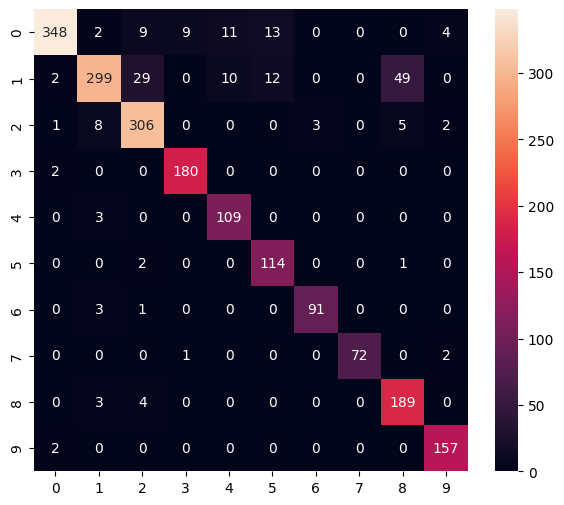

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.88      0.93       396
           1       0.94      0.75      0.83       401
           2       0.87      0.94      0.91       325
           3       0.95      0.99      0.97       182
           4       0.84      0.97      0.90       112
           5       0.82      0.97      0.89       117
           6       0.97      0.96      0.96        95
           7       1.00      0.96      0.98        75
           8       0.77      0.96      0.86       196
           9       0.95      0.99      0.97       159

    accuracy                           0.91      2058
   macro avg       0.91      0.94      0.92      2058
weighted avg       0.91      0.91      0.91      2058



In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Convert to model for Tensorflow-Lite

In [16]:
# Save as a model dedicated to inference
model.save(model_save_path)

In [17]:
# Transform model (quantization)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\Jordan\AppData\Local\Temp\tmpplcblegt\assets


INFO:tensorflow:Assets written to: C:\Users\Jordan\AppData\Local\Temp\tmpplcblegt\assets


7264

# Inference test

In [18]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [19]:
# Get I / O tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [20]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [21]:
%%time
# Inference implementation
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: total: 0 ns
Wall time: 0 ns


In [22]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[1.95787430e-01 2.53106914e-02 9.53517592e-05 1.46545514e-01
 7.27625682e-10 1.92704785e-04 1.52588459e-02 1.02064244e-01
 2.79781443e-06 5.14742434e-01 3.02519372e-17 2.54003814e-15
 9.27643683e-17 3.00287579e-14 1.75256686e-15 1.39572342e-15
 2.84337475e-14 3.16175105e-14 1.91992418e-14 1.53582354e-14]
9
